# Modelos lineares

Vamos inicializar algumas bibliotecas padrão de nosso trabalho:

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

RAND_SEED = 42

np.random.seed(RAND_SEED)

# Revisão

## Modelo

Em todo problema de machine learning uma amostra de entrada é um vetor

$$\mathbf{x} = (x_1, x_2, \cdots, x_n)$$

de $n$ valores (características ou *features*). (Usaremos fontes em negrito para indicar vetores e matrizes.)

Em notação matricial, os vetores são matrizes-coluna:

$$
\mathbf{x} = \left[
\begin{matrix}
x_1 \\
x_2 \\
\vdots \\
x_n
\end{matrix}
\right]
$$

Vamos trabalhar com as duas notações (vetores e matrizes-coluna) de modo intercambiável, e que ficará evidente no contexto de uso.

Uma amostra de saída é um valor que se supõe depender da entrada. Se o valor de saída é contínuo temos um problema de **regressão**, e se o valor é categórico (trata-se de uma classe ou categoria) temos um problema de **classificação**.

Um modelo de machine learning é uma função que permite estimar o valor de saída para uma dada amostra de entrada. Esta função depende de **parâmetros** $\mathbf{\theta}$, que representam os "ajustes" desta função. Ou seja:

$$y_{\text{estimado}} = \hat{y} = h_{\mathbf{\theta}}\left(\mathbf{x}\right)$$

## Erro

O objetivo principal em um projeto de machine learning é encontrar um modelo que produza boas estimativas, ou seja, estimativas que se aproximem dos valores reais. *Treinamento* é ajustar os parâmetros $\mathbf{\theta}$ para conseguir **em média** melhores estimativas.

Uma estimativa é boa se o **erro** entre a estimativa e o valor real é baixo. A definição do erro depende do problema em questão. Se for uma regressão, então uma medida razoável de erro para uma dada amostra é a diferença entre o valor real e o valor estimado:

$$\text{erro}\left(\mathbf{x}, y_{real}, \mathbf{\theta} \right) = y_{\text{estimado}} - y_{\text{real}} = h_{\mathbf{\theta}}\left(\mathbf{x}\right) - y_{\text{real}}$$

Se desejamos uma métrica positiva de erro, podemos adotar:

- o valor absoluto do erro: $\left| \,\text{erro}\left(\mathbf{x}, y_{real}, \mathbf{\theta} \right) \,\right|$, ou
- o valor quadrático do erro: $\text{erro}\left(\mathbf{x}, y_{real}, \mathbf{\theta} \right)^2$

Se for um problema de classificação, então o erro pode ser simplesmente o resultado da comparação entre a classe real e a classe estimada.

## Erro sobre um conjunto de amostras

Será que um modelo é bom? Uma forma de responder esta questão é avaliar o erro médio do classificador sobre um conjunto de exemplos.

Para ilustrar essa ideia, vamos considerar um problema de regressão. Seja $\left(\mathbf{x}^{(1)}, \mathbf{x}^{(2)}, \cdots, \mathbf{x}^{(m)}\right)$ uma lista de $m$ amostras, e $\left(y^{(1)}, y^{(2)}, \cdots, y^{(m)}\right)$ os valores dependentes correspondentes.

Vamos representar essa informação na forma de uma matriz $\mathbf{X}$ para as amostras e um vetor $\mathbf{y}$ para os valores dependentes, ou seja:

$$
\mathbf{X} = \left[
\begin{matrix}
\left(\mathbf{x}^{(1)}\right)^{T} \\
\left(\mathbf{x}^{(2)}\right)^{T} \\
\vdots \\
\left(\mathbf{x}^{(m)}\right)^{T} \\
\end{matrix}
\right] = \left[
\begin{matrix}
x_{1}^{(1)} & x_{2}^{(1)} & \cdots & x_{n}^{(1)} \\
x_{1}^{(2)} & x_{2}^{(2)} & \cdots & x_{n}^{(2)} \\
\vdots & \vdots & \ddots & \vdots \\
x_{1}^{(m)} & x_{2}^{(m)} & \cdots & x_{n}^{(m)} \\
\end{matrix}
\right]
\  \text{,} \quad
\mathbf{y}_{\text{real}} = \left[
\begin{matrix}
y^{(1)} \\
y^{(1)} \\
\vdots \\
y^{(1)} \\
\end{matrix}
\right]
$$

O erro quadrático médio é (surpresa!) a média do erro quadrático sobre o conjunto de amostras:

$$
MSE\left(\mathbf{\theta} \, | \, \mathbf{X}, \mathbf{y} \right) =
\frac{1}{m} \sum_{i=1}^{m} \left(h_{\mathbf{\theta}}\left(\mathbf{x}^{(i)}\right) - y^{(i)}\right)^2
$$

É comum usarmos a raiz quadrada de $MSE\left(\mathbf{\theta} \, | \, \mathbf{X}, \mathbf{y} \right)$, para que o erro esteja descrito nas mesmas unidades de medida da variável dependente. Obtemos então a medida de erro médio conhecida como RMSE (*Root Mean Squared Error*), muito usada em problemas de regressão.

$$
\displaystyle \text{RMSE}\left(\mathbf{\theta} \, | \, \mathbf{X}, \mathbf{y} \right)
=
\sqrt{MSE\left(\mathbf{\theta} \, | \, \mathbf{X}, \mathbf{y} \right)}
=
\sqrt{
    \frac{1}{m}
    \sum_{i=1}^{m}
        \left(h_{\mathbf{\theta}}\left(\mathbf{x}^{(i)}\right) - y^{(i)}\right)^2
}
$$

## Treinamento

Treinar um modelo é achar os parâmetros do modelo que minimizam o erro médio deste em um conjunto de amostras de treinamento. Por exemplo, para o problema de regressão e usando RMSE como métrica de desempenho, temos matematicamente:

$$
\mathbf{\theta}_{\text{opt}} = \text{arg min}_{\mathbf{\theta}}\left\{\text{RMSE}\left(\mathbf{\theta} \, | \, \mathbf{X}_{\text{train}}, \mathbf{y}_{\text{train}} \right)\right\}
$$

Para procurar $\mathbf{\theta}_{\text{opt}}$ temos que aplicar um **algoritmo de treinamento** ao nosso modelo e nossas amostras de treinamento. Para cada modelo e métrica de desempenho existe um algoritmo de treinamento. Alguns algoritmos de treinamento são versáteis, e são aplicáveis a vários tipos de modelo - por exemplo, o *método do máximo declive* (**gradient descent**).

$$\text{modelo} = \text{Modelo}()$$

$$\mathbf{\theta}_{\text{opt}} = \text{modelo.fit}(\mathbf{X}_{\text{train}}, \mathbf{y}_{\text{train}})$$

Existem parâmetros que não são ajustáveis neste processo, e seus valores devem ser passados para o algoritmo de treinamento. Por exemplo: número máximo de iterações do método de treinamento, valor do parâmetro de regularização, etc. Estes parâmetros extras sao chamados de **hiperparâmetros**. Portanto, é mais correto escrever a expressão acima como:

$$\text{modelo} = \text{Modelo}(\mathbf{\theta}_{\text{hiper}})$$

$$\mathbf{\theta}_{\text{opt}} = \text{modelo.fit}(\mathbf{X}_{\text{train}}, \mathbf{y}_{\text{train}})$$

## Usando o modelo treinado para fazer predições

Finalmente, quando temos o modelo treinado (ou seja, encontramos os parâmetros ótimos $\mathbf{\theta}$), podemos usá-lo para fazer predições: seja $\mathbf{x}_{\text{novo}}$ uma nova amostra, então a predição $\hat{y}$ do modelo é calculada como:

$$\hat{y} = h_{\mathbf{\theta}_{\text{opt}}; \mathbf{\theta}_{\text{hiper}}}\left(\mathbf{x}_{\text{novo}}\right)$$

Ou, em pseudo-código:

$$\text{modelo} = \text{Modelo}(\mathbf{\theta}_{\text{hiper}})$$

$$\mathbf{\theta}_{\text{opt}} = \text{modelo.fit}(\mathbf{X}_{\text{train}}, \mathbf{y}_{\text{train}})$$

$$\hat{y} = \text{modelo.predict}(\mathbf{x}_{\text{novo}})$$

**Atividade:**

Isto que foi apresentado é a essência do machine learning para classificação e regressão. Tente explicar, com a formulação matemática adequada, os seguintes conceitos:

- Amostra

- Modelo

- RMSE

- Treinamento

- Predição

O objetivo é conseguir explicar e escrever as fórmulas correspondentes SEM PRECISAR OLHAR NO MATERIAL DE SUPORTE. Estude o material de suporte o quanto quiser, feche o notebook, e responda a atividade no papel. *(NÃO PRECISA ENTREGAR)*

# Regressão linear

## Modelo

Em um modelo de regressão linear, desejamos obter uma predição de valor $\hat{y}$ como uma combinação linear dos valores das *features* mais um termo de *offset*.

$$\mathbf{\theta} = (\theta_0, \theta_1, \cdots, \theta_n)$$

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_n x_n$$

Em notação matricial:

$$\hat{y} = \mathbf{x}^{T} \mathbf{\theta}$$

onde o vetor $\mathbf{x}$ de características da amostra é formado pelas características originais e por uma "característica extra" que é o valor $1$. Ou seja:

$$\mathbf{x} = \left[
\begin{matrix}
1 \\
x_1 \\
x_2 \\
\vdots \\
x_n
\end{matrix}
\right]$$

Para um dado conjunto de treinamento, podemos representar as várias quantidades deste problema em uma notação matricial:

$$
\mathbf{X}_{\text{train}} = \left[
\begin{matrix}
\left(\mathbf{x}_{\text{train}}^{(1)}\right)^{T} \\
\left(\mathbf{x}_{\text{train}}^{(2)}\right)^{T} \\
\vdots \\
\left(\mathbf{x}_{\text{train}}^{(m)}\right)^{T}
\end{matrix}
\right] = \left[
\begin{matrix}
1 & x_1^{(1)} & x_2^{(1)} & \cdots & x_n^{(1)} \\
1 & x_1^{(2)} & x_2^{(2)} & \cdots & x_n^{(2)} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_1^{(m)} & x_2^{(m)} & \cdots & x_n^{(m)} \\
\end{matrix}
\right]
\  \text{,} \quad
\mathbf{y}_{\text{train}} = \left[
\begin{matrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(m)} \\
\end{matrix}
\right]
\  \text{,} \quad
\mathbf{\theta} = \left[
\begin{matrix}
\theta_0 \\
\theta_1 \\
\vdots \\
\theta_n
\end{matrix}
\right]
\  \text{,} \quad
\hat{\mathbf{y}} = \left[
\begin{matrix}
\hat{y}^{(1)} \\
\hat{y}^{(2)} \\
\vdots \\
\hat{y}^{(m)}
\end{matrix}
\right] = \mathbf{X}_{\text{train}} \mathbf{\theta}
$$

## Erro quadrático

Para um conjunto de amostras de treinamento, o erro quadrático médio é dado por:

$$
MSE\left(\mathbf{\theta} \, | \, \mathbf{X}_{\text{train}}, \mathbf{y}_{\text{train}}\right) =
\frac{1}{m}
  \sum_{i=1}^{m} \left(
    \hat{y}^{(i)} - y^{(i)}
  \right)^2 =
\frac{1}{m}
  \sum_{i=1}^{m} \left(
    (\mathbf{x}^{(i)})^{T} \mathbf{\theta} - y^{(i)}
  \right)^2
$$

Em notação matricial,

$$
MSE\left(\mathbf{\theta} \, | \, \mathbf{X}_{\text{train}}, \mathbf{y}_{\text{train}} \right) = \\
\frac{1}{m} (\mathbf{X}_{\text{train}} \mathbf{\theta} - \mathbf{y}_{\text{train}})^T
            (\mathbf{X}_{\text{train}} \mathbf{\theta} - \mathbf{y}_{\text{train}}) = \\
\frac{1}{m} (\mathbf{\theta}^{T} \mathbf{X}_{\text{train}}^{T} - \mathbf{y}_{\text{train}}^{T})
            (\mathbf{X}_{\text{train}} \mathbf{\theta} - \mathbf{y}_{\text{train}}) = \\
\frac{1}{m} (
    \mathbf{\theta}^{T} \mathbf{X}_{\text{train}}^{T} \mathbf{X}_{\text{train}} \mathbf{\theta}
  - \mathbf{\theta}^{T} \mathbf{X}_{\text{train}}^{T} \mathbf{y}_{\text{train}}
  - \mathbf{y}_{\text{train}}^{T} \mathbf{X}_{\text{train}} \mathbf{\theta}
  + \mathbf{y}_{\text{train}}^{T} \mathbf{y}_{\text{train}}) = \\
\frac{1}{m} (
    \mathbf{\theta}^{T} \mathbf{X}_{\text{train}}^{T} \mathbf{X}_{\text{train}} \mathbf{\theta}
  - 2 \mathbf{\theta}^{T} \mathbf{X}_{\text{train}}^{T} \mathbf{y}_{\text{train}}
  + \mathbf{y}_{\text{train}}^{T} \mathbf{y}_{\text{train}})
$$

Note que se $\mathbf{X}_{\text{train}}$ e $\mathbf{y}_{\text{train}}$ são quantidades fixas, a única variável aqui é $\mathbf{\theta}$.

## Gradiente do erro

Cálculo matricial: https://en.wikipedia.org/wiki/Matrix_calculus

Extraindo as derivadas parciais da função $MSE\left(\mathbf{\theta} \, | \, \mathbf{X}_{\text{train}}, \mathbf{y}_{\text{train}} \right)$ em relação aos termos $\theta_i$ temos:

$$
\nabla_{\mathbf{\theta}} MSE\left(\mathbf{\theta} \, | \, \mathbf{X}_{\text{train}}, \mathbf{y}_{\text{train}} \right) =
\frac{1}{m} (
    2 \mathbf{X}_{\text{train}}^{T} \mathbf{X}_{\text{train}} \mathbf{\theta}
  - 2 \mathbf{X}_{\text{train}}^{T} \mathbf{y}_{\text{train}})
$$

## A Equação Normal

Nosso objetivo é achar o vetor de parâmetros $\mathbf{\theta}$ que minimiza $MSE\left(\mathbf{\theta} \, | \, \mathbf{X}_{\text{train}}, \mathbf{y}_{\text{train}} \right)$. Para tanto, vamos resolver a equação

$$\nabla_{\mathbf{\theta}} MSE\left(\mathbf{\theta} \, | \, \mathbf{X}_{\text{train}}, \mathbf{y}_{\text{train}} \right) = \mathbf{0}$$

onde $\mathbf{0}$ é uma matriz-coluna de $m$ zeros.

$$
\begin{align*}
\nabla_{\mathbf{\theta}} MSE\left(\mathbf{\theta} \, | \, \mathbf{X}_{\text{train}}, \mathbf{y}_{\text{train}} \right) & = \mathbf{0} \\
\Leftrightarrow \frac{1}{m} (
    2 \mathbf{X}_{\text{train}}^{T} \mathbf{X}_{\text{train}} \mathbf{\theta}
  - 2 \mathbf{X}_{\text{train}}^{T} \mathbf{y}_{\text{train}}) & = \mathbf{0} \\
\Leftrightarrow \mathbf{X}_{\text{train}}^{T} \mathbf{X}_{\text{train}} \mathbf{\theta} & = \mathbf{X}_{\text{train}}^{T} \mathbf{y}_{\text{train}} \\
\Leftrightarrow \mathbf{\theta} & = (\mathbf{X}_{\text{train}}^{T} \mathbf{X}_{\text{train}})^{-1} \mathbf{X}_{\text{train}}^{T} \mathbf{y}_{\text{train}} \\
\end{align*}
$$

Esta última linha é conhecida como **equação normal** do problema de regressão linear. Será que corresponde a um ponto de mínimo? Sim, podemos também calcular a segunda derivada e mostrar que a solução obtida realmente é um ponto de mínimo. Como só temos um único ponto de mínimo, trata-se então de um ***mínimo global*** - algo muito desejável em qualquer modelo de *machine learning*!

## Usando a equação normal para treinar uma regressão linear

Chegamos finalmente ao nosso primeiro algoritmo de treinamento do curso de machine learning! Vamos treinar um modelo de regressão linear usando a equação normal.

A vantagem de se usar a equação normal é que a solução final é obtida diretamente por uma fórmula. A desvantagem é que o cálculo desta fórmula não escala bem com o número de *features* do problema, porque a matriz quadrada $\mathbf{X}_{\text{train}}^{T} \mathbf{X}_{\text{train}}$ deve ser invertida e esta tem tamanho $n \times n$. Se o número de *features* for muito alto (e.g. pixels em uma imagem) o custo desta operação é alto.

**Atividade:** Qual a complexidade computacional de se inverter uma matriz?

**R:**

**Atividade:** Qual a complexidade computacional do treinamento do regressor linear via equação normal, em termos de:

- $n$: número de *features*, e
- $m$: número de amostras de treinamento?

**R:**

**Atividade:** Em função dos resultados acima, você recomendaria o uso da equação normal em um problema:

1. Com poucas amostras de treinamento e muitas *features*?

2. Com muitas amostras de treinamento e poucas *features*?

**R:**

Vamos gerar alguns pontos de dados para testar nossa regressão linear. Nossa função linear real será $f(x) = 3 x + 4$ e á esta adicionaremos ruído gaussiano de média zero e desvio padrão unitário:

In [ ]:
m = 100

X = 2 * np.random.rand(m, 1)  # Gera m pontos aleatórios entre 0 e 2.
ruido = np.random.randn(m, 1)  # Gera um ruido gaussiano de desvio padrão 1.0

y = 4 + 3 * X + ruido  # Nosso sinal detectado.


**Pergunta:** Quais são os parâmetros ótimos esperados ao se treinar um modelo de regressão linear sobre dados gerados por esta código?

**R:**

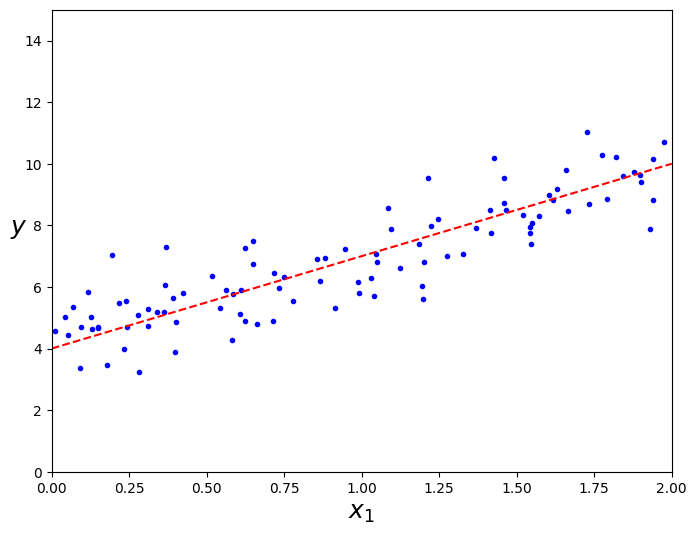

In [ ]:
X_aux = np.array([[0.0], [2.0]])
y_aux = 4 + 3 * X_aux

plt.figure(figsize=(8, 6))
plt.plot(X, y, "b.")
plt.plot(X_aux, y_aux, "r--")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.show()


Para usar a equação normal temos que aumentar a matriz de amostras de treinamento com uma coluna extra de valores $1$:

In [ ]:
print(f'Tamanho original da matriz de amostras: {X.shape}')
print(f'Algumas das amostras originais:\n{X[:5]}')


Tamanho original da matriz de amostras: (100, 1)
Algumas das amostras originais:
[[0.74908024]
 [1.90142861]
 [1.46398788]
 [1.19731697]
 [0.31203728]]


In [ ]:
# Adicionando uma coluna de 1s.
X_b = np.c_[np.ones((m, 1)), X]

print(f'Tamanho da matriz de amostras aumentada: {X_b.shape}')
print(f'Algumas das amostras da matriz aumentada:\n{X_b[:5]}')


Tamanho da matriz de amostras aumentada: (100, 2)
Algumas das amostras da matriz aumentada:
[[1.         0.74908024]
 [1.         1.90142861]
 [1.         1.46398788]
 [1.         1.19731697]
 [1.         0.31203728]]


Agora vamos usar a equação normal para calcular os parâmetros ótimos:

In [ ]:
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best


array([[4.21509616],
       [2.77011339]])

Chegamos perto do resultado ideal!

**Atividade:** Mude o número de pontos de treinamento e veja se os parâmetros ótimos se aproximam dos parâmetros ideais.

Vamos ver como o modelo se comporta para fazer predições:

In [ ]:
# Criando um vetor de amostras fictícias de teste.
X_test = np.linspace(0.0, 2.0, num=100).T

# Calculando os valores de y segundo a equação normal.
X_test_b = np.c_[np.ones((len(X_test), 1)), X_test]
y_test = X_test_b.dot(theta_best)


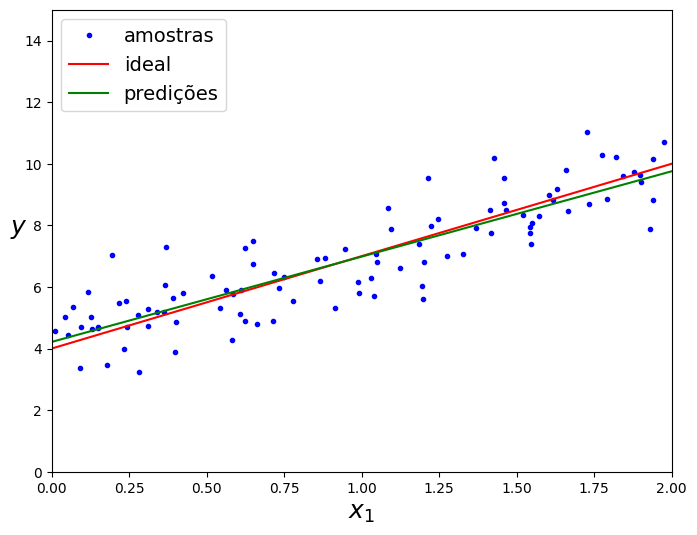

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(X, y, "b.", label='amostras')
plt.plot(X_aux, y_aux, "r", label='ideal')
plt.plot(X_test, y_test, "g-", label='predições')
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([0, 2, 0, 15])
plt.show()


Vamos comparar nosso preditor com o regressor linear do scikit-learn:

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_


(array([4.21509616]), array([[2.77011339]]))

Resultados identicos!

#  Gradient Descent

Um outro método de treinamento de uma regressão linear é o método do máximo declive (*gradient descent*). Este método também serve para outros regressores e classificadores, é bastante genérico - usamos bastante o gradient descent em redes neurais!

Este método se baseia na observação seguinte:

- O gradiente da função de erro médio é um vetor no espaço de características que aponta na direção de maior crescimento do erro.
- Logo, se desejo achar os parâmetros que minimizam o erro, basta andar na direção contrária do gradiente do erro!

Ou seja, partindo de um "chute" aleatório $\mathbf{\theta}_{0}$ dos valores dos parâmetros, vamos iterativamente melhorar nossos parâmetros através de pequenos incrementos neste na direção oposta ao gradiente da função de erro:

$$
\mathbf{\theta}_{i + 1} = \mathbf{\theta}_{i} - \eta \nabla_{\mathbf{\theta}} MSE\left(\mathbf{\theta}_{i} \, | \, \mathbf{X}_{\text{train}}, \mathbf{y}_{\text{train}} \right)
$$

O **hiperparâmetro** $\eta$ é chamado de *passo de aprendizado* (*learning step*) do algoritmo.

Continuamos iterando através desta fórmula até que não tenhamos mais mudanças significativas em $\mathbf{\theta}$, ou seja: para uma pequena tolerância $\epsilon > 0$

$$
\left| \, \mathbf{\theta}_{i + 1} - \mathbf{\theta}_{i} \, \right| < \epsilon
$$

O **hiperparâmetro** $\epsilon$ controla a precisão desejada na solução final. Se a tolerância for muito pequena pode ser que o algoritmo não convirja rapidamente. Neste caso é comum definir um número máximo de iterações através de outro **hiperparâmetro** ``max_iter``.

**Atividade:** Estude o material do livro texto (Géron), capítulo 4 e responda:

- Qual a diferença entre batch gradient descent, stochastic gradient descent, e mini-batch gradient descent?
- O que acontece quando $\eta$ é muito pequeno?
- O que acontece quando $\eta$ é muito grande?
- Quais as classes do scikit-learn que implementam regressão linear usando a equação normal no treinamento? Quais usam gradient descent em alguma de suas formas?

**R:**

# Regressão polinomial

E se os dados não se ajustam a uma linha reta (ou um hiperplano, no caso geral)? Considere o seguinte problema:

In [ ]:
np.random.seed(42)

# Vamos gerar m = 100 amostras de exemplo.
m = 100

# As coordenadas x são geradas aleatoriamente entre -3 e 3.
X = 6 * np.random.rand(m, 1) - 3

# Computando os valores de y
y = 0.5 * X**2 + X + 2

# Adicionando ruido.
y += 3.0 * np.random.randn(m, 1)


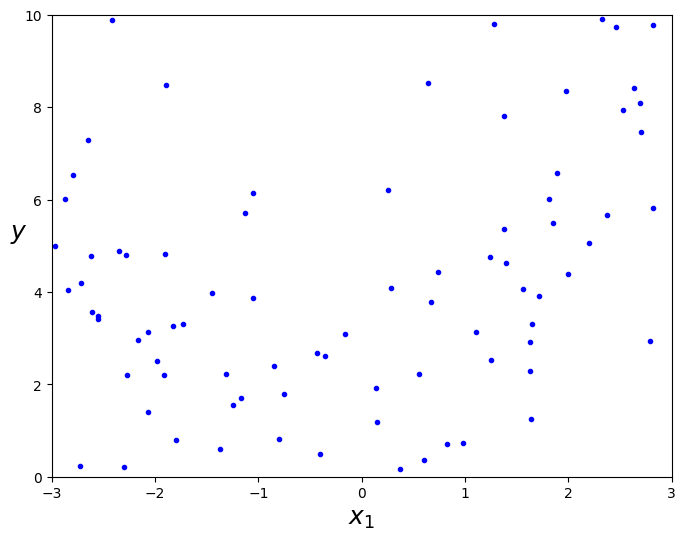

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.show()


Obviamente não podemos atingir um bom *fit* com uma linha reta! A solução para nosso problema é criar novas *features* com valores polinomiais:

In [ ]:
print('Tamanho original da matriz de amostras: {}'.format(X.shape))
print('Algumas das amostras originais:\n{}'.format(X[:5]))


Tamanho original da matriz de amostras: (100, 1)
Algumas das amostras originais:
[[-0.75275929]
 [ 2.70428584]
 [ 1.39196365]
 [ 0.59195091]
 [-2.06388816]]


In [ ]:
# Adicionando uma coluna de 1s e uma coluna de x**2.
X_b = np.c_[np.ones((m, 1)), X, X**2]

print('Tamanho da matriz de amostras aumentada: {}'.format(X_b.shape))
print('Algumas das amostras da matriz aumentada:\n{}'.format(X_b[:5]))


Tamanho da matriz de amostras aumentada: (100, 3)
Algumas das amostras da matriz aumentada:
[[ 1.         -0.75275929  0.56664654]
 [ 1.          2.70428584  7.3131619 ]
 [ 1.          1.39196365  1.93756281]
 [ 1.          0.59195091  0.35040587]
 [ 1.         -2.06388816  4.25963433]]


Usamos novamente a equação normal para achar os parâmetros ótimos (ou o gradient descent também serve!)

In [ ]:
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best


array([[1.34403744],
       [0.8010068 ],
       [0.6936879 ]])

Agora vamos ver como ficou nosso *fit*:

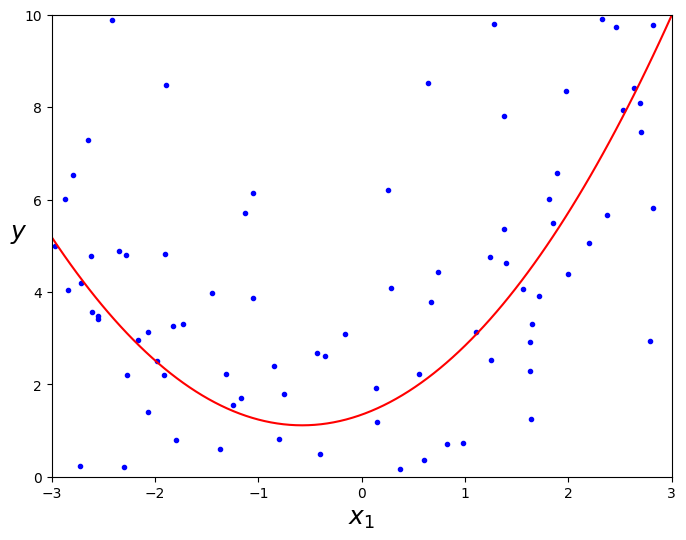

In [ ]:
X_test = np.linspace(-3, 3, num=100).T
X_test_b = np.c_[np.ones((m, 1)), X_test, X_test**2]
y_test = X_test_b.dot(theta_best)

plt.figure(figsize=(8, 6))
plt.plot(X, y, "b.")
plt.plot(X_test, y_test, "r-")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.show()


Para criar *features* polinomiais de um grau qualquer em scikit-learn podemos usar a classe ``PolynomialFeatures``:

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Nota: include_bias=False porque o bias (termo constante) já estará incluso no regressor linear.
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

print(X.shape)
print(X_poly.shape)


(100, 1)
(100, 2)


In [ ]:
print(X[0])
print(X_poly[0])


[-0.75275929]
[-0.75275929  0.56664654]


Podemos então fazer um regressor linear com estes novos dados:

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_


(array([1.34403744]), array([[0.8010068, 0.6936879]]))

Compare os resultados obtidos aqui com aqueles da equação normal obtidos anteriormente.

Assim como o uso de *features* polinomiais leva a um modelo com melhor ajuste, podemos também usar outras funções como *features*, tais como $\text{log}()$, $\text{sin}()$, etc.

# Overfitting versus underfitting

O que acontece se o grau do *fit* polinomial for muito baixo? E se for muito alto? Vamos experimentar um pouco:

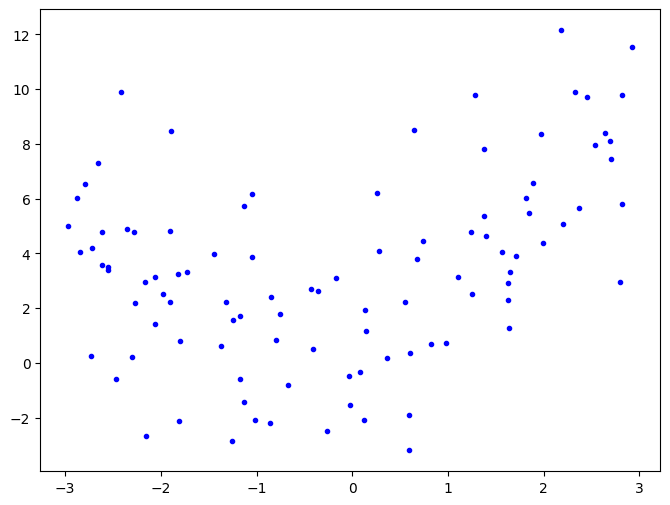

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

plt.figure(figsize=(8, 6))
plt.plot(X, y, "b.", linewidth=3)


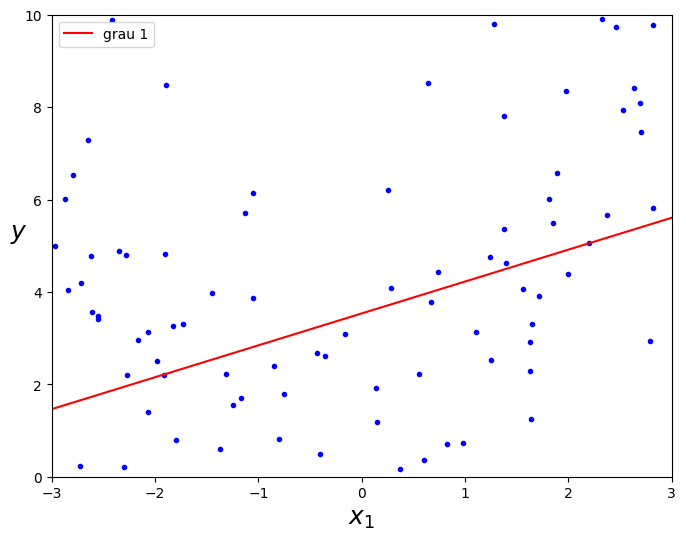

In [ ]:
# Experimento 1: grau baixo.
poly_reg_1 = Pipeline([
    ("poly_features", PolynomialFeatures(degree=1, include_bias=False)),
    ("std_scaler", StandardScaler()),
    ("lin_reg", LinearRegression()),
])
poly_reg_1.fit(X, y)
y_test_1 = poly_reg_1.predict(X_test.reshape(-1, 1))

plt.figure(figsize=(8, 6))
plt.plot(X, y, "b.", linewidth=3)
plt.plot(X_test, y_test_1, 'r-', label='grau 1')

plt.legend(loc="upper left")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.show()


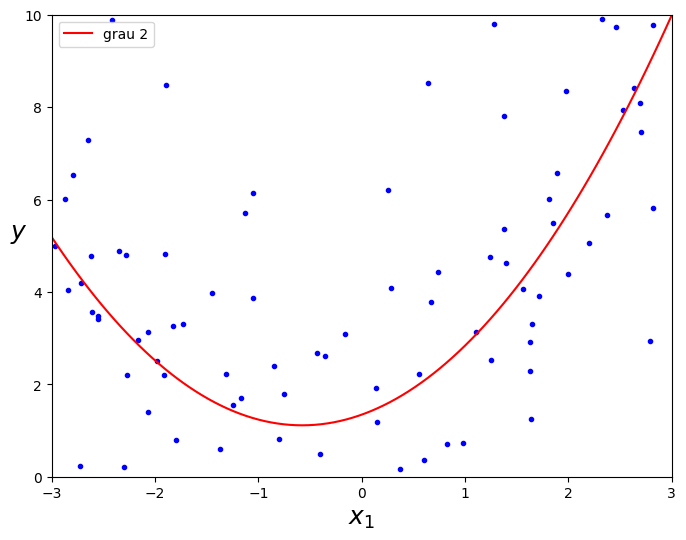

In [ ]:
# Experimento 2: grau adequdo.
poly_reg_2 = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("std_scaler", StandardScaler()),
    ("lin_reg", LinearRegression()),
])
poly_reg_2.fit(X, y)
y_test_2 = poly_reg_2.predict(X_test.reshape(-1, 1))

plt.figure(figsize=(8, 6))
plt.plot(X, y, "b.", linewidth=3)
plt.plot(X_test, y_test_2, 'r-', label='grau 2')

plt.legend(loc="upper left")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.show()


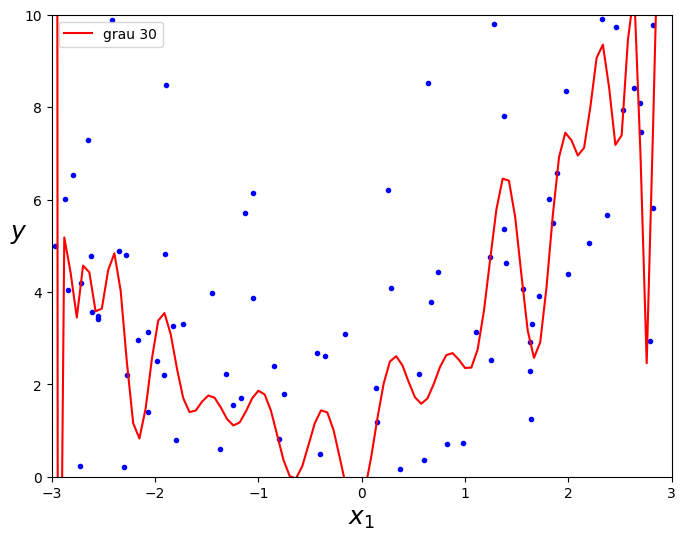

In [ ]:
# Experimento 3: grau muito alto.
poly_reg_30 = Pipeline([
    ("poly_features", PolynomialFeatures(degree=30, include_bias=False)),
    ("std_scaler", StandardScaler()),
    ("lin_reg", LinearRegression()),
])
poly_reg_30.fit(X, y)
y_test_30 = poly_reg_30.predict(X_test.reshape(-1, 1))

plt.figure(figsize=(8, 6))
plt.plot(X, y, "b.", linewidth=3)
plt.plot(X_test, y_test_30, 'r-', label='grau 30')

plt.legend(loc="upper left")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.show()


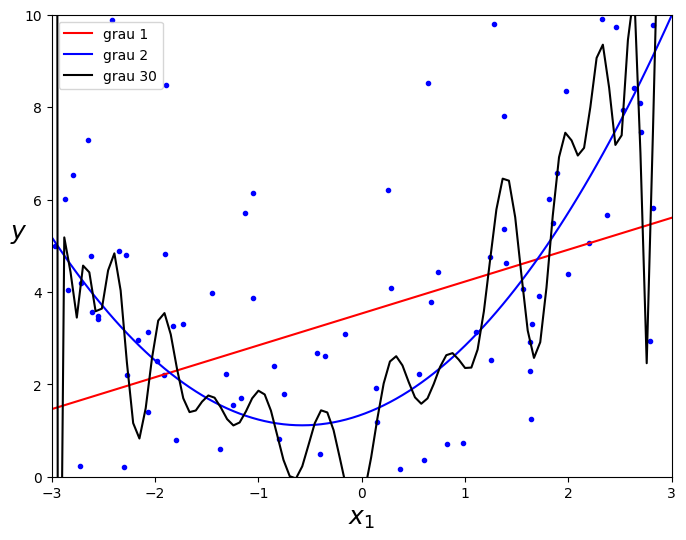

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(X, y, "b.", linewidth=3)
plt.plot(X_test, y_test_1, 'r-', label='grau 1')
plt.plot(X_test, y_test_2, 'b-', label='grau 2')
plt.plot(X_test, y_test_30, 'g-', label='grau 30')

plt.legend(loc="upper left")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.show()


A curva verde, correspondente ao *fit* de grau 30, apresenta *overfitting*. Ao tentar se ajustar o melhor possível aos pontos de dados, a curva tende a apresentar comportamento exagerado fora destes.

Uma característica marcante do *overfitting* é que o sistema perde sua capacidade de fazer predições de boa qualidade quando não está na vizinhança de um ponto de treinamento. Dizemos que o sistema não **generaliza** bem. Para observar a capacidade de generalização de um sistema podemos usar a estratégia de validação cruzada e obter uma medida mais realista do RMSE do classificador:

In [ ]:
from sklearn.model_selection import cross_val_score


def experiment(reg, X, y, degree):
    scores = np.sqrt(-cross_val_score(
        reg,
        X,
        y,
        cv=5,
        scoring='neg_mean_squared_error',
    ))
    print(f'Fit de grau {degree}:')
    print(f'RMSE = {scores}')
    print(f'média = {scores.mean()}, std = {scores.std()}')


experiments = (
    (1, poly_reg_1),
    (2, poly_reg_2),
    (30, poly_reg_30),
)

for degree, regressor in experiments:
    experiment(regressor, X, y, degree)


Fit de grau 1:
RMSE = [3.25056527 2.99126785 3.45587426 3.12595575 3.47048654]
média = 3.25882993334792, std = 0.18597758468524206
Fit de grau 2:
RMSE = [2.18236222 2.7568279  3.17716785 2.71130239 2.9047708 ]
média = 2.7464862321599535, std = 0.3256136989469981
Fit de grau 30:
RMSE = [  5.00074167   4.38701644   4.20691508 857.80652076   3.84096247]
média = 175.04843128235407, std = 341.37925099180876


Note que o erro de treinamento conta uma história diferente:

In [ ]:
from sklearn.metrics import mean_squared_error


def final_train_error(X, y, reg):
    reg.fit(X, y)
    y_pred = reg.predict(
        X)  # Sim, estou predizendo no conjunto de treinamento.
    return np.sqrt(mean_squared_error(y_pred, y))


def params_to_str(pipeline):
    aux = pipeline.named_steps['lin_reg']
    return 'intercept = {}, coefs = {}'.format(aux.intercept_, aux.coef_)


for degree, regressor in experiments:
    train_error = final_train_error(X, y, regressor)
    print(f'Fit de grau {degree}: RMSE = {train_error}')

for degree, regressor in experiments:
    print(f'Modelo de grau {degree}: {params_to_str(regressor)}')


Fit de grau 1: RMSE = 3.2229958136237546
Fit de grau 2: RMSE = 2.6447576443130156
Fit de grau 30: RMSE = 2.3389022227418206
Modelo de grau 1: intercept = [3.41091787], coefs = [[1.22607716]]
Modelo de grau 2: intercept = [3.41091787], coefs = [[1.42257955 1.85245033]]
Modelo de grau 30: intercept = [3.41091728], coefs = [[ 1.11809912e+01  1.45735458e+02 -7.20208008e+02 -8.78481924e+03
   2.47209269e+04  2.27691152e+05 -4.42614732e+05 -3.25500675e+06
   4.64015902e+06  2.89362554e+07 -3.09825577e+07 -1.71181685e+08
   1.39464579e+08  7.02788032e+08 -4.38752709e+08 -2.05465905e+09
   9.84171087e+08  4.33577719e+09 -1.58415659e+09 -6.61990786e+09
   1.81663792e+09  7.24273127e+09 -1.44871139e+09 -5.53439426e+09
   7.63449616e+08  2.80409186e+09 -2.38985734e+08 -8.46284010e+08
   3.36442315e+07  1.15138208e+08]]


Podemos aqui observar uma característica marcante do *overfitting* versus *underfitting*:

- **overfitting**:
    - O modelo é **complexo demais** (permite sobreajuste, ou *overfitting*)
    - erro de treinamento **baixo**
    - erro médio de teste **geralmente alto** (mas **ocasionalmente baixo**)
    - **variância alta** do erro de teste
    
- **underfitting**:
    - O modelo é **simples demais** (não permite bom ajuste)
    - erro de treinamento **alto**
    - erro de teste **consistentemente alto**
    - **variância baixa** do erro de teste

## Curvas de aprendizado

O que quer dizer que um modelo é muito complexo? É um modelo que tem parâmetros de ajuste em excesso *em relação ao volume de dados de teste*. Um modelo tido como complexo para um conjunto pequeno de dados pode ser um modelo muito simples ao se considerar um conjunto maior de dados. Vamos explorar esse conceito em um experimento:

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


def plot_learning_curves(model, X, y, ax1, ax2, step=5):
    # Separa 20% para validação.
    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=RAND_SEED,
    )

    train_errors, val_errors = [], []

    # Para cada tamanho do conjunto de treinamento...
    for m in range(1, len(X_train)):
        mean_RMSE_train = 0.0
        mean_RMSE_val = 0.0

        count = 0
        for i in range(0, len(X_train) - m, step):
            # Ajusta modelo com apenas m amostras de treinamento.
            model.fit(X_train[i:(i + m)], y_train[i:(i + m)])

            # Faz a previsão sobre o conjunto de treinamento
            # (para obter o erro de treinamento)
            # e sobre o conjunto de validação.
            y_train_predict = model.predict(X_train[i:(i + m)])
            y_val_predict = model.predict(X_val)

            # Calcula o valor do RMSE
            RMSE_train = np.sqrt(
                mean_squared_error(
                    y_train_predict,
                    y_train[i:(i + m)],
                ))
            RMSE_val = np.sqrt(mean_squared_error(y_val_predict, y_val))

            mean_RMSE_train += RMSE_train
            mean_RMSE_val += RMSE_val
            count += 1

        mean_RMSE_train /= count
        mean_RMSE_val /= count

        # Armazena ambos os valores de RMSE.
        train_errors.append(mean_RMSE_train)
        val_errors.append(mean_RMSE_val)

    plt.figure(figsize=(8, 6))
    plt.plot(np.sqrt(train_errors), "r-", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")
    plt.axis(ax1)
    plt.legend(loc="upper right", fontsize=14)
    plt.xlabel("Training set size", fontsize=14)
    plt.ylabel("RMSE", fontsize=14)

    plt.figure(figsize=(8, 6))
    plt.plot(np.sqrt(train_errors), "r-", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")
    plt.axis(ax2)
    plt.legend(loc="upper right", fontsize=14)
    plt.xlabel("Training set size", fontsize=14)
    plt.ylabel("RMSE", fontsize=14)
    plt.show()


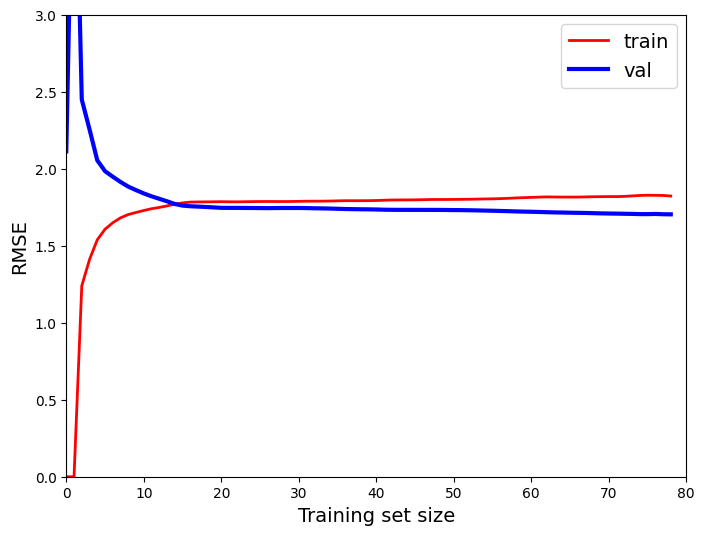

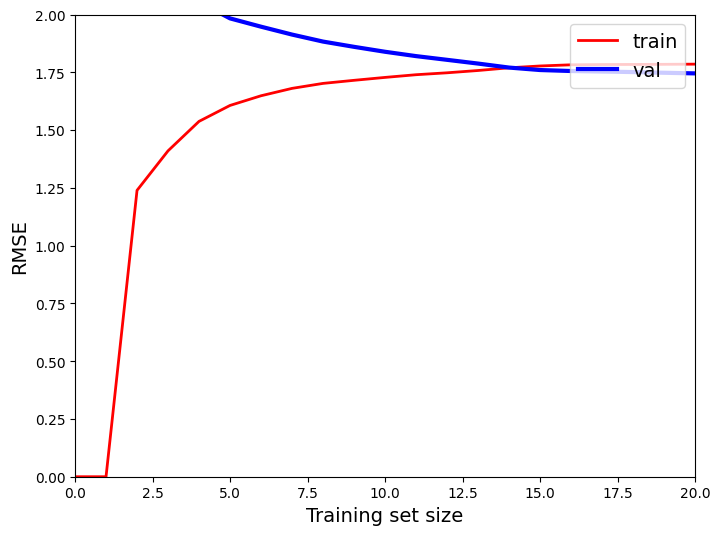

In [ ]:
plot_learning_curves(poly_reg_1, X, y, [0, 80, 0, 3], [0, 20, 0, 2], 1)


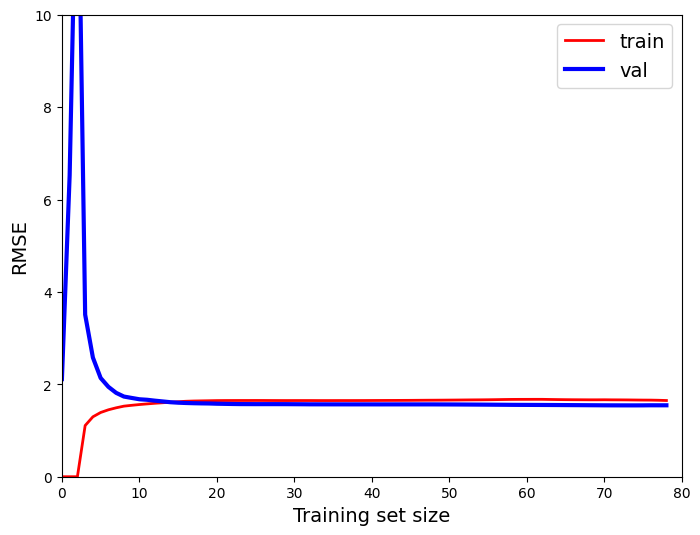

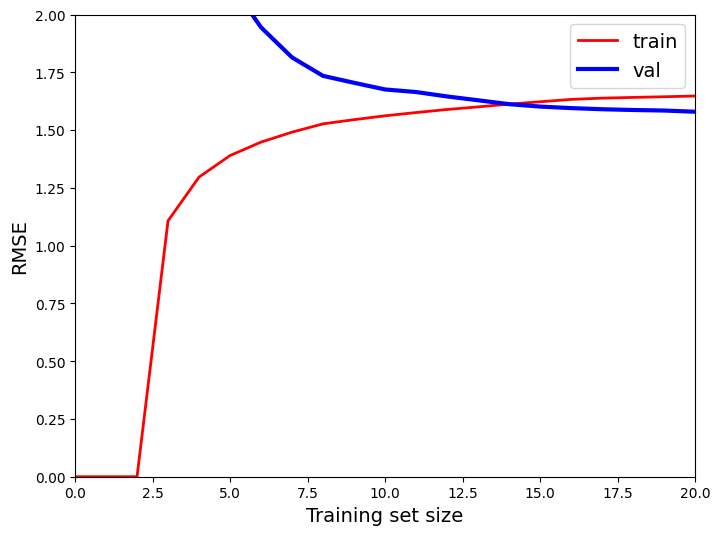

In [ ]:
plot_learning_curves(poly_reg_2, X, y, [0, 80, 0, 1e1], [0, 20, 0, 2], 1)


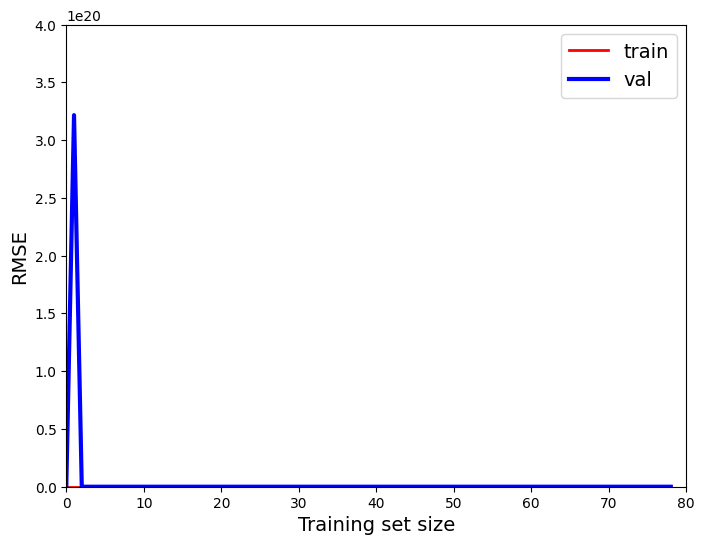

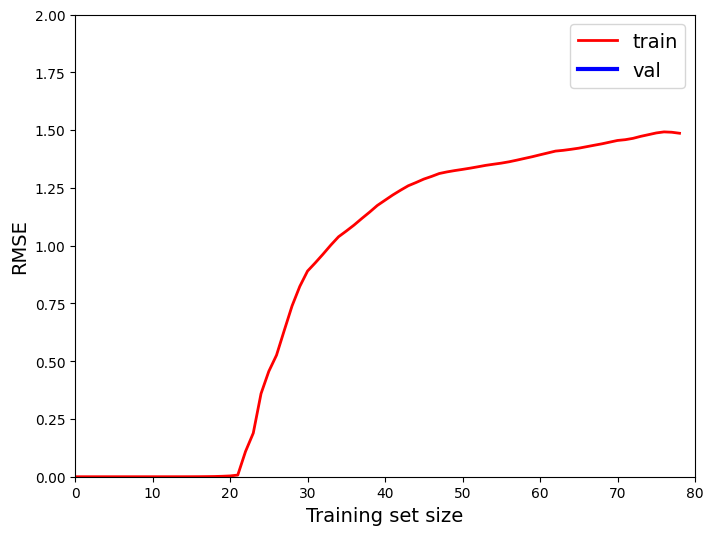

In [ ]:
plot_learning_curves(poly_reg_30, X, y, [0, 80, 0, 4e20], [0, 80, 0, 2], 1)


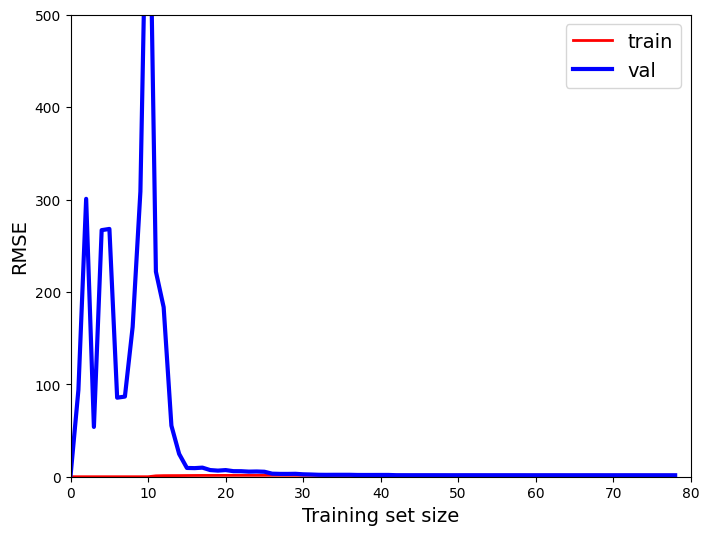

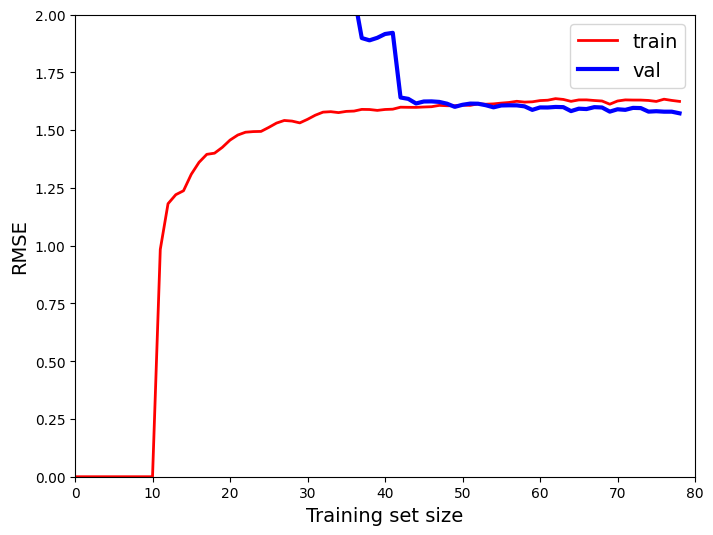

In [ ]:
poly_reg_10 = Pipeline([
    ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
    ("std_scaler", StandardScaler()),
    ("lin_reg", LinearRegression()),
])

plot_learning_curves(poly_reg_10, X, y, [0, 80, 0, 500], [0, 80, 0, 2])


Podemos observar quando um ajuste passa de *overfit* para ajuste normal conforme o número de dados de treinamento aumenta!

---

**Atividade:**

Explique:

- Porque o erro do modelo ``poly_reg_1`` é maior que o erro do modelo ``poly_reg_2``?

- Porque o erro do modelo ``poly_reg_30`` é maior que o erro do modelo ``poly_reg_2``?

- Porque na curva RMSE versus tamanho do conjunto de treinamento observamos, para o modelo de grau 10, que o erro de treinamento é zero até que o conjunto de treinamento tenha mais de 10 amostras?

- Para as curvas relacionadas a modelos complexos, eventualmente o erro tende a aproximadamente $\text{RMSE} = 1$ neste problema-exemplo. Explique em termos de *bias*, variância, e erro intrínseco. (Compare com os dados originais.)

**R:**

```









```


---